# Letter Combinations of a Phone Number

<a href="https://leetcode.com/problems/letter-combinations-of-a-phone-number/">\
<img alt="Question Number" src="https://img.shields.io/badge/Question-17-blue"/></a>
![Difficulty](https://img.shields.io/badge/Difficulty-Medium-yellow) ![First Attempted](https://img.shields.io/badge/First%20Attempted-2023--08--15-blue)
![Status](https://img.shields.io/badge/Status-Correct-green) ![Tag](https://img.shields.io/badge/Tag-HashMap-orange)
![Tag](https://img.shields.io/badge/Tag-String-orange) ![Tag](https://img.shields.io/badge/Tag-Backtracking-orange)

```{contents}
:local:
```

In [1]:
%config InlineBackend.figure_format = 'svg'

from __future__ import annotations

from typing import Optional, List, Union, Any

from IPython.display import display, HTML
import rich
from typing import List
from itertools import product

import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[2])
sys.path.append(parent_dir)


from omnivault.dsa.trees.binary import BinaryTreeNode
from omnivault.dsa.trees.utils import build_binary_tree_from_list_preorder
from omnivault.dsa.trees.utils import print_binary_tree
from omnivault.dsa.utils import compare_test_case, compare_test_cases

## Problem

Given a string containing digits from `2-9` inclusive, return all possible
letter combinations that the number could represent. Return the answer **in any
order**.

A mapping of digits to letters (just like on the telephone buttons) is given
below. Note that `1` does not map to any letters.

```{figure} ../../assets/backtracking/17-letter-combinations-of-a-phone-number.png
---
name: 17-letter-combinations-of-a-phone-number-image
width: 400px
---
Image.
```

## Example

```bash
Input: digits = "32"
Output: ["da","db","dc","ea","eb","ec","fa","fb","fc"]
```

## Intuition

At the core, this is a combinatorial problem where you want to generate all
possible combinations from a set of options for each digit. Let's break the
problem by first considering a single digit case, then extend it to multiple
digits.

### Single-Digit Case

Start with the trivial case: one digit, say `3`, which maps to the letters "d",
"e", "f". The result is simply these letters, each forming a 1-letter
combination: ["d", "e", "f"].

### Multi-Digit Case: 2-Digits as an Example

Consider a 2-digit input, `32`.

1. Take the first digit `3`, and look up its corresponding letters: `"d"`,
   `"e"`, `"f"`.
2. For each of these letters, fix it as the starting letter for a combination.
3. Move to the next digit "2", which maps to the letters `"a"`, `"b"`, `"c"`.
4. For each starting letter from step 2, append each letter from this step. For
   example, starting with `"d"`, we append `"a"`, `"b"`, and `"c"`, to get the
   combinations `"da"`, `"db"`, and `"dc"`, then move on to the next starting
   letter `"e"`, to get `"ea"`, `"eb"`, and `"ec"`, and lastly `"f"` to get
   `"fa"`, `"fb"`, and `"fc"`.

Now we've solved the 2-digit problem by reducing it to two 1-digit problems.

### Extending to N-Digits

The same reasoning generalizes to an N-digit input. You first solve the
$(N-1)$-digit problem to get all possible combinations of the first $N-1$
digits. Each of these becomes a starting string to which you append each letter
corresponding to the $N$-th digit. Essentially, you've recursively decomposed an
N-digit problem into an $(N-1)$-digit problem and a 1-digit problem.

### Summary

The problem is solved through a recursive decomposition: an N-digit problem is
reduced to solving an $(N-1)$-digit problem and a 1-digit problem. The base case
is the 1-digit problem, which is trivial to solve. With this recursive
decomposition, you can systematically generate all combinations for any
$N$-digit input.

## Assumptions

1. **String Concatenation Cost**: It's assumed that the cost of string
   concatenation is constant time, which is an approximation and might not hold
   for very long strings.

2. **Unique Output Strings**: The mapping of digits to alphabets is unique,
   meaning each digit will always map to the same set of alphabets. This is
   relevant for the idempotence of the function.

3. **Constant Mapping**: The mapping of digits to alphabets is assumed to be
   constant and known _a priori_.

4. **Input Validity**: The input string only contains digits and lies within the
   constraints defined; no validation for erroneous input is considered.

## Constraints

1. **0 <= digits.length <= 4**: This constraint limits the input size. It
   impacts both the space and time complexity of the problem. For an $N$-digit
   number, you can have up to $3^N$ to $4^N$ combinations, which could be
   computationally expensive for large $N$. However, given the constraint
   $N \leq 4$, the computational requirements remain manageable.

2. **digits[i] is a digit in the range ['2', '9']**: This constraint limits the
   choices for each digit to at least 3 (for '2' mapping to "abc") and at most 4
   (for '7' mapping to "pqrs"). It simplifies the problem by not requiring
   handling for digits like '0' or '1', which traditionally don't map to any
   alphabets in this context.

## Test Cases

### Simple Test Cases

1. **Single Digit**: `digits = "2"` Expected Output: `["a", "b", "c"]`

2. **Two Digits, 3x3**: `digits = "32"` Expected Output:
   `["da", "db", "dc", "ea", "eb", "ec", "fa", "fb", "fc"]`

### Complex Test Cases

1. **Four Digits, 3x4x3x3**: `digits = "2736"` Expected Output: All combinations
   of `"apdm"`, `"apdn"`, ..., `"csfo"`.

2. **Four Digits, All have 4 choices**: `digits = "7979"` Expected Output: All
   combinations of "ptpt", "ptpu", ..., "susu".

## Edge Cases

1. **Empty Input**: `digits = ""` Expected Output: `[]`. An empty input should
   result in an empty list.

2. **Single Digit with 4 Choices**: `digits = "7"` Expected Output:
   `["p", "q", "r", "s"]`. It tests whether the function can handle the maximum
   number of choices for a single digit.

3. **All Digits Same**: `digits = "2222"` Expected Output: All combinations of
   "aaaa", "aaab", ..., "cccc". This tests the function's ability to handle
   repetitive digits.

4. **Non-Sequential Digits**: `digits = "279"` Expected Output: All combinations
   of "apa", "apb", ..., "csu". This ensures that the function works for
   non-sequential digits.

## Walkthrough / Whiteboarding

Detailed walkthrough of the problem-solving process.

## Theoretical Best Time Complexity

Discussion of the theoretical best time complexity for this problem.

## Theoretical Best Space Complexity

Discussion of the theoretical best space complexity for this problem.

## Space-Time Tradeoff

Analysis of the tradeoff between space and time complexity for the problem.

## Solution (Potentially Multiple)

### Intuition

At the core, this is a combinatorial problem where you want to generate all
possible combinations from a set of options for each digit. One way to
intuitively think about it is as a tree structure. For instance, if the input
digits are "32", then the first digit "3" maps to letters `["d", "e", "f"]` and
the second digit "2" maps to `["a", "b", "c"]`. The root of the tree could start
with an empty string, and each layer of the tree represents appending one of the
letters corresponding to the next digit. We would then traverse this tree to
generate all combinations.

The diagram below illustrates this idea. The root node is an empty string, and
each layer represents appending one of the letters corresponding to the next
digit. The leaf nodes represent the final combinations.

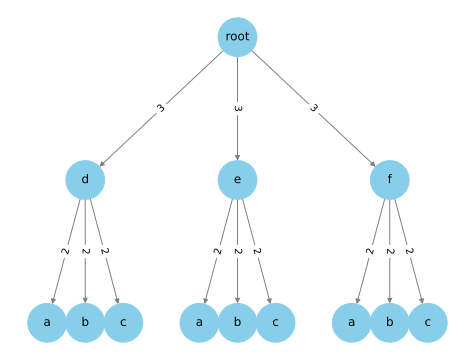

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the tree
T = nx.DiGraph()
edges = [
    ("root", "d"),
    ("root", "e"),
    ("root", "f"),
    ("d", "da"),
    ("d", "db"),
    ("d", "dc"),
    ("e", "ea"),
    ("e", "eb"),
    ("e", "ec"),
    ("f", "fa"),
    ("f", "fb"),
    ("f", "fc"),
]

# Add edges to the graph
T.add_edges_from(edges)

# Define custom positions
pos = {
    "root": (0, 0),
    "d": (-2, -1),
    "e": (0, -1),
    "f": (2, -1),
    "da": (-2.5, -2),
    "db": (-2, -2),
    "dc": (-1.5, -2),
    "ea": (-0.5, -2),
    "eb": (0, -2),
    "ec": (0.5, -2),
    "fa": (1.5, -2),
    "fb": (2, -2),
    "fc": (2.5, -2),
}

# Node labels
labels = {
    node: node[-1] if node not in ["root", "d", "e", "f"] else node
    for node in T.nodes()
}

# Edge labels
edge_labels = {
    (u, v): '3' if v in ["d", "e", "f"] else '2'
    for u, v in T.edges()
}

# Draw the graph
nx.draw(
    T,
    pos,
    labels=labels,
    with_labels=True,
    node_color="skyblue",
    node_size=1500,
    edge_color="gray",
)
nx.draw_networkx_edge_labels(T, pos, edge_labels=edge_labels)
plt.show()

The below diagram directly illustrates how at the leaf nodes, you "have
information" about the entire combination, which is the path from the root to
the leaf.

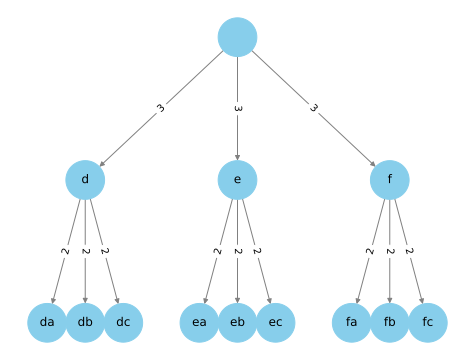

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the tree
T = nx.DiGraph()
edges = [
    ("", "d"),
    ("", "e"),
    ("", "f"),
    ("d", "da"),
    ("d", "db"),
    ("d", "dc"),
    ("e", "ea"),
    ("e", "eb"),
    ("e", "ec"),
    ("f", "fa"),
    ("f", "fb"),
    ("f", "fc"),
]

T.add_edges_from(edges)

# Define custom, symmetric positions
pos = {
    "": (0, 0),
    "d": (-2, -1),
    "e": (0, -1),
    "f": (2, -1),
    "da": (-2.5, -2),
    "db": (-2, -2),
    "dc": (-1.5, -2),
    "ea": (-0.5, -2),
    "eb": (0, -2),
    "ec": (0.5, -2),
    "fa": (1.5, -2),
    "fb": (2, -2),
    "fc": (2.5, -2),
}

# Define edge labels
edge_labels = {
    ("", "d"): "3",
    ("", "e"): "3",
    ("", "f"): "3",
    ("d", "da"): "2",
    ("d", "db"): "2",
    ("d", "dc"): "2",
    ("e", "ea"): "2",
    ("e", "eb"): "2",
    ("e", "ec"): "2",
    ("f", "fa"): "2",
    ("f", "fb"): "2",
    ("f", "fc"): "2",
}

# Draw the tree
nx.draw(
    T,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=1500,
    edge_color="gray",
)
nx.draw_networkx_edge_labels(T, pos, edge_labels=edge_labels)
plt.show()

More concretely, we can represent this combinatorial problem as a state space
tree, where each node represents a partial or complete solution to the problem.
The root represents the initial state with an empty string, while each level of
the tree represents the choices available at that particular step, dictated by
the associated digit in the phone number. By the time you reach a leaf node,
you've made a selection for each digit, thereby forming a complete solution to
the problem.

#### Refining the Intuition

1. **Root Node**: The root node is the starting point, representing an empty
   string. This is where no choices have been made, and it encapsulates the
   initial state of the problem.

2. **Internal Nodes**: Nodes at the second level ("d", "e", "f") represent
   making a choice based on the first digit ("3"). These choices are extended by
   the third level of the tree, which includes nodes like "da", "db", "dc", and
   so forth. Each such node signifies a path from the root, reflecting the
   choices made at each step.

3. **Leaf Nodes**: These are the terminal nodes that represent complete
   solutions, like "da", "db", etc. Each leaf node is a valid combination of
   letters for the given phone number.

4. **Edge Labels**: The labels on the edges represent the digit being used to
   generate the next set of choices. For example, an edge labeled "3" means we
   are considering the choices mapped from the digit "3", and an edge labeled
   "2" means the choices come from the digit "2".

5. **Depth of the Tree**: The depth of the tree corresponds to the length of the
   phone number. For example, for a 2-digit number, the tree will have a depth
   of 2.

6. **Traversal and Solution Space**: When you traverse from the root to any
   leaf, you essentially traverse a path in the solution space defined by the
   phone number. The number of leaves will be the number of possible
   combinations.

#### State Space Trees

1. **Enumerative State Space Tree**: This is the actual tree where each node
   represents a state, and the children of each node represent the states
   reachable from the current state. Here, the nodes at level $i$ represent all
   possible states of the problem after $i$ decisions. In the example, the
   states are strings formed from mapping the digits to letters.

2. **Implicit State Space Tree**: This is a conceptual tree that represents the
   solution space rather than actual states. It is used mainly for theoretical
   analysis and isn't explicitly generated.

Both types of state space trees capture the nature of the problem:
combinatorial, incremental construction of solutions, and the decisions made at
each step. Your diagram serves as an enumerative state space tree and
effectively visualizes the problem and its solution space.

### Visualization

The visualization for digits `32` can be seen below:

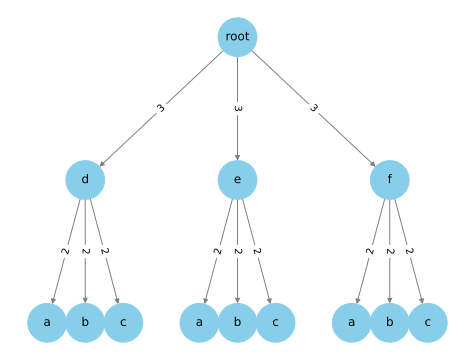

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the tree
T = nx.DiGraph()
edges = [
    ("root", "d"),
    ("root", "e"),
    ("root", "f"),
    ("d", "da"),
    ("d", "db"),
    ("d", "dc"),
    ("e", "ea"),
    ("e", "eb"),
    ("e", "ec"),
    ("f", "fa"),
    ("f", "fb"),
    ("f", "fc"),
]

# Add edges to the graph
T.add_edges_from(edges)

# Define custom positions
pos = {
    "root": (0, 0),
    "d": (-2, -1),
    "e": (0, -1),
    "f": (2, -1),
    "da": (-2.5, -2),
    "db": (-2, -2),
    "dc": (-1.5, -2),
    "ea": (-0.5, -2),
    "eb": (0, -2),
    "ec": (0.5, -2),
    "fa": (1.5, -2),
    "fb": (2, -2),
    "fc": (2.5, -2),
}

# Node labels
labels = {
    node: node[-1] if node not in ["root", "d", "e", "f"] else node
    for node in T.nodes()
}

# Edge labels
edge_labels = {
    (u, v): '3' if v in ["d", "e", "f"] else '2'
    for u, v in T.edges()
}

# Draw the graph
nx.draw(
    T,
    pos,
    labels=labels,
    with_labels=True,
    node_color="skyblue",
    node_size=1500,
    edge_color="gray",
)
nx.draw_networkx_edge_labels(T, pos, edge_labels=edge_labels)
plt.show()

### Fitting in to Constraints Satisfaction Problem (CSP) Framework

#### Domains $\mathcal{D}$

Let $\mathcal{D}$ be the mapping that associates each digit
$d \in \{2, 3, 4, 5, 6, 7, 8, 9\}$ to a set of letters.

$$
\mathcal{D} = \{D_2, D_3, D_4, D_5, D_6, D_7, D_8, D_9\}
$$

where $D_i$ is the set of letters that digit $i$ can map to. We did not start
the index at $0$ because the digits start at $2$, so it is easier to read.

For example, $D_2$ is the set of letters that digit $2$ can map to, which is
$D_2 = \{a, b, c\}$.

More concretely, we have:

$$
\begin{aligned}
D_2 &= \{a, b, c\} \\
D_3 &= \{d, e, f\} \\
D_4 &= \{g, h, i\} \\
D_5 &= \{j, k, l\} \\
D_6 &= \{m, n, o\} \\
D_7 &= \{p, q, r, s\} \\
D_8 &= \{t, u, v\} \\
D_9 &= \{w, x, y, z\} \\
\end{aligned}
$$

#### Variables $\mathcal{V}$

The variables $\mathcal{V}$ are the digits in the input string defined as:

$$
\begin{aligned}
\mathcal{V} &= \{V_2, V_3, V_4, V_5, V_6, V_7, V_8, V_9\} \\
            &= \{2, 3, 4, 5, 6, 7, 8, 9\}
\end{aligned}
$$

_Each variable $V_i$ represents a digit in the input string and can take on any
value from its corresponding domain $D_i$._

For example, $V_2$ represents the digit $2$ in the input string and can take on
any value from its corresponding domain $D_2 = \{a, b, c\}$:

$$
V_2 = a \quad \text{or} \quad V_2 = b \quad \text{or} \quad V_2 = c
$$

However, we can be more precise and align $\mathcal{V}$ with the input string
$S = s_1s_2\ldots s_n$, we could define ours variables $\mathcal{V}$ based on
the length $N$ and the particular digits in $S$. For example:

$$
\mathcal{V} = \{V_{s_1}, V_{s_2}, \ldots, V_{s_n}\}
$$

where $V_{s_i}$ is the variable corresponding to the digit $s_i$ in the input
string $S$.

For example, if the input string is $S = 2736$, then the variables $\mathcal{V}$
are:

$$
\mathcal{V} = \{V_2, V_7, V_3, V_6\} = \{2, 7, 3, 6\}
$$

#### Constraints $\mathcal{C}$

For this problem, $\mathcal{C}$ is essentially empty ($\mathcal{C} = \{\}$)
because each digit $V_i$ can independently take any value from its corresponding
domain $D(V_i)$, without any inter-variable constraints.

#### Problem Representation

Given a phone number $S = s_1s_2\ldots s_n$, the problem can be formulated as
follows:

$$
\begin{aligned}
\text{Cartesian Product} &= \prod_{s_i \in S} D(V_{s_i}) \\
                         &= D(V_{s_1}) \times D(V_{s_2}) \times \ldots \times D(V_{s_n})
\end{aligned}
$$

More concretely, for the phone number $S = 2736$, the problem can be formulated
as:

$$
\begin{aligned}
\text{Cartesian Product} &= \prod_{s_i \in S} D(V_{s_i}) \\
                         &= D(V_2) \times D(V_7) \times D(V_3) \times D(V_6) \\
                         &= \{a, b, c\} \times \{p, q, r, s\} \times \{d, e, f\} \times \{m, n, o\}
\end{aligned}
$$

which yields the set of all possible letter combinations for the phone number
$S = 2736$. For example, the combination "apdm" is in the Cartesian product.

### Algorithm

See [backtracking](../concept.md) for a refresher on backtracking.

#### Pseudocode

Let $N$ be the length of the input digit string, and let $D_i$ represent the set
of possible letters corresponding to the $i^{th}$ digit (indexed from 0).

````{prf:algorithm} Pseudocode
:label: 17-letter-combinations-of-a-phone-number-pseudocode

Algorithm: `letterCombinations(digits)`

Input: `digits` (string of digits with length $N$)

Output: `paths` (list of strings)

```
Define function "letterCombinations(digits)"
    if digits is empty
        Return empty list
    Initialize an empty list "paths"
    Define function "backtrack(path, start_index)"
        If start_index = N
            Add path to "paths"
            Return
        For each letter in D_{digits[start_index]}
            Append letter to path
            Call backtrack(path, start_index + 1)
            Remove last letter from path
    Call backtrack("", 0)
    Return paths
```
````

#### Mathematical Representation

Let $S$ be the input string with length $N$. The problem can be represented as a
decision tree where each node has a set of children nodes corresponding to the
next digit's possible letters. We will recursively traverse this tree to
generate all possible paths from root to leaf, where each leaf is a valid letter
combination.

In formal terms, this is akin to calculating the Cartesian product:

$$
\prod_{i=0}^{N-1} D_i
$$

#### Correctness

##### Claim

The algorithm correctly generates all possible combinations of letters
corresponding to the digits in the input string.

##### Proof

```{prf:proof}
We will use induction to prove that the algorithm is correct.

1. **Base Case**: For $N = 0$, the function immediately returns an empty list.
   This is correct since there are no letters that correspond to an empty input
   digit string.

2. **Inductive Hypothesis**: Assume that for some $k < N$, calling the function
   `backtrack(path, start_index)` correctly produces all combinations from the
   $k^{th}$ digit onwards and appends them to `paths`.

3. **Inductive Step**: Consider when `backtrack` is called with
   `start_index = k`. The function iterates through all the possible letters
   corresponding to the $k^{th}$ digit, appends them to `path`, and calls itself
   recursively with `start_index = k + 1`. By the inductive hypothesis, this
   will generate all valid combinations from the $(k+1)^{th}$ digit onwards.
```

Thus, by mathematical induction, we prove that the algorithm correctly generates
all possible combinations of letters corresponding to the input string's digits.

### Implementation

If we follow the template in [backtracking](../concept.md) as well as coupled
with the algorithm defined earlier:

```python
def backtrack(root, path):
    if is_leaf(root): # base case, leaf=complete assignment
        output(path)
        return

    # iterate all possible candidates.
    for edge in get_edges(root):
        path.add(edge)
        backtrack(root + 1, path)
        path.pop()
```

We can write the following code:

In [5]:
class Solution:
    def letterCombinations(self, digits: str) -> List[str]:
        digits_len: int = len(digits)
        digits_to_letter: Dict[int, str] = {
            2: "abc",
            3: "def",
            4: "ghi",
            5: "jkl",
            6: "mno",
            7: "pqrs",
            8: "tuv",
            9: "wxyz",
        }

        # base case 1: need not be in backtrack function because
        # it guarantees an immediate return.
        if len(digits) == 0:
            return []

        # is path considered a root?
        def backtrack(path: List[str], start_index: int = 0) -> None:

            if start_index == digits_len:  # or len(path) == len(digits)
                # hit leaf add solution to it no constraints here
                paths.append("".join(path))
                return None

            variable = digits[start_index]  # V_i = 3

            # {'d', 'e', 'f'} (possible letters)
            domain = digits_to_letter[int(variable)]

            # start loop through the possible letters (Domain) of the
            # CURRENT DIGIT (Variable)

            for letter in domain:
                # add letter to current path
                path.append(letter)

                # move on to next digit while still in the current letter
                backtrack(path, start_index + 1)
                # if dfs hits base case, it should return and get out of stack
                # call, so we need to pop
                path.pop()  # "da" -> "d" then branch out from "d" to "db" etc

        paths: List[str] = []
        backtrack(path=[], start_index=0)
        return paths

1. Start with empty soln: path=""
2. recursively Extend select a var from V and assign a value,
    1. for instance, if we select 2 from V, we can have choices of assigning
       either a,b or c.
    2. so you treat the edge as 2 for each edge connecting to a,b,and c.
    3. so now we assign a
    4. do not need to prune no constraints
    5. so now we look next edge, which is edge for variable 3
    6. and we choose d
    7. then we got ad since we reached leaf.

### Tests

We use the `compare_test_cases_dsa` function to compare the actual and expected
outputs of the test cases. We also use Python's `itertools.product` to generate
the Cartesian product, which in this case would give you all the letter
combinations for the input digits.

In [6]:
def expected_combinations(digits: str) -> List[str]:
    digits_to_letter = {
        "2": "abc",
        "3": "def",
        "4": "ghi",
        "5": "jkl",
        "6": "mno",
        "7": "pqrs",
        "8": "tuv",
        "9": "wxyz",
    }

    if digits == "":
        return []

    # Generate the list of letter lists for each digit
    letter_lists = [list(digits_to_letter[digit]) for digit in digits]

    # Generate the Cartesian product of the letter lists
    all_combinations = product(*letter_lists)

    # Convert the tuples to strings and collect them into a list
    return ["".join(combination) for combination in all_combinations]

# Prepare test data
actual_list = [
    Solution().letterCombinations("2"),
    Solution().letterCombinations("23"),
    Solution().letterCombinations("2736"),
    Solution().letterCombinations("7979"),
    Solution().letterCombinations(""),
    Solution().letterCombinations("7"),
    Solution().letterCombinations("2222"),
    Solution().letterCombinations("279"),
]

expected_list = [
    expected_combinations("2"),
    expected_combinations("23"),
    expected_combinations("2736"),
    expected_combinations("7979"),
    expected_combinations(""),
    expected_combinations("7"),
    expected_combinations("2222"),
    expected_combinations("279"),
]

description_list = [
    "Single digit",
    "Two digits 3x3",
    "Four digits 3x4x3x3",
    "Four digits all have 4 choices",
    "Empty Input",
    "Single digit with 4 choices",
    "All digits same",
    "Non-Sequential Digits",
]

# Run the tests
compare_test_cases(
    actual_list=actual_list,
    expected_list=expected_list,
    description_list=description_list,
)

### Time Complexity

The time complexity for the worst case is $\mathcal{O}(4^N \cdot N)$, where $N$
is the length of the input string. Why so?

First, we must be clear that the number $4$ is the maximum number of letters
that a digit can map to. For example, the digit $7$ maps to the letters
$\{p, q, r, s\}$, which is a set of 4 letters. The digit $2$ maps to the letters
$\{a, b, c\}$, which is a set of 3 letters. This $4$ is **not referring to the
number of digits in the input string**.

Secondly, the worse case is if the input string contains only digits that map to
4 letters. For example, the input string $S = 777$ is considered a worst case
because each digit maps to 4 letters.

Typically, to count the time complexity of a recursive tree, we usually count
the number of nodes in the tree and examine how much work is done at each node.

We just examine the case where there's two digits in the input string, for
instance $77$. The recursive tree would look like this:

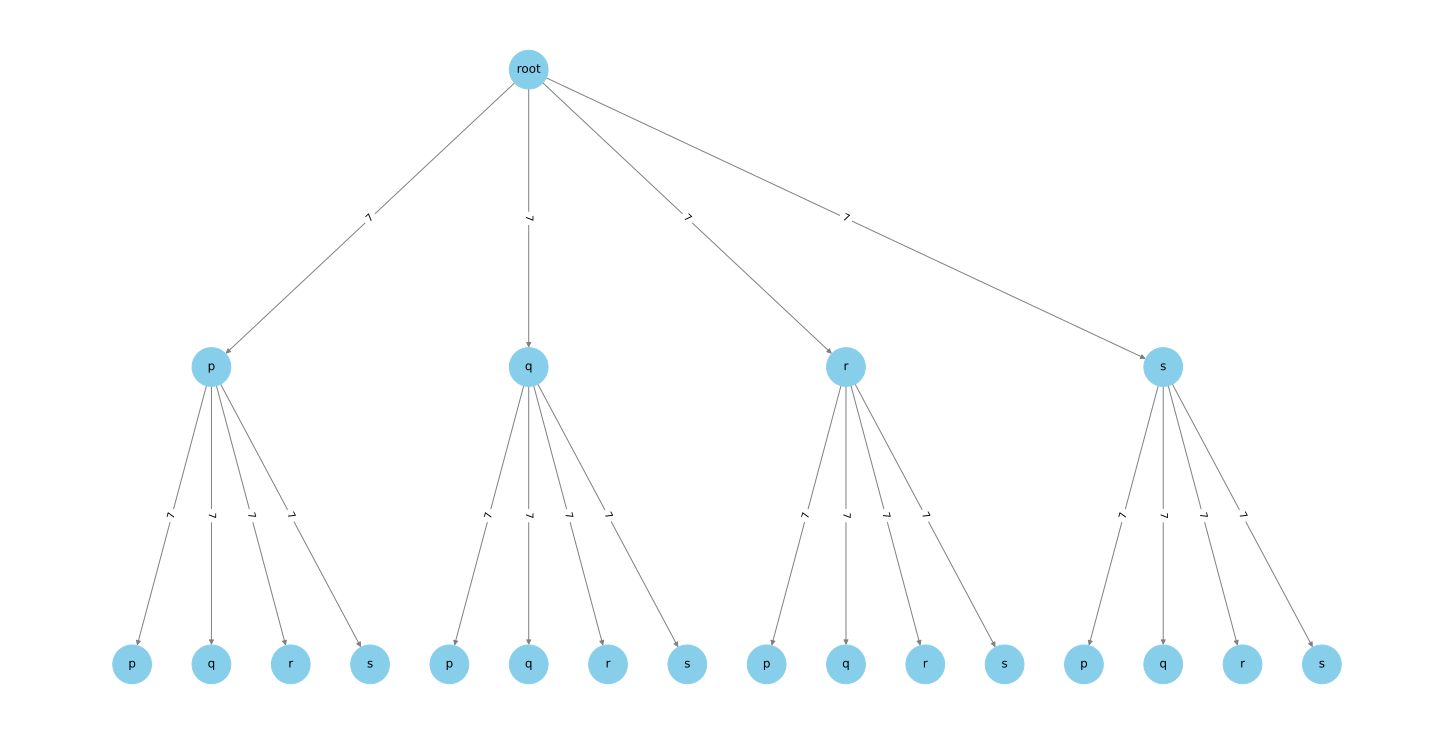

In [7]:
# Define the tree for digits 77
import networkx as nx
import matplotlib.pyplot as plt

import networkx as nx
import matplotlib.pyplot as plt

# Define the tree
T = nx.DiGraph()
edges = [
    ("root", "p"),
    ("root", "q"),
    ("root", "r"),
    ("root", "s"),
    ("p", "pp"),
    ("p", "pq"),
    ("p", "pr"),
    ("p", "ps"),
    ("q", "qp"),
    ("q", "qq"),
    ("q", "qr"),
    ("q", "qs"),
    ("r", "rp"),
    ("r", "rq"),
    ("r", "rr"),
    ("r", "rs"),
    ("s", "sp"),
    ("s", "sq"),
    ("s", "sr"),
    ("s", "ss"),
]

# Add edges to the graph
T.add_edges_from(edges)

# Define custom positions
pos = {
    "root": (0, 0),
    "p": (-2, -1),
    "q": (0, -1),
    "r": (2, -1),
    "s": (4, -1),
    "pp": (-2.5, -2),
    "pq": (-2, -2),
    "pr": (-1.5, -2),
    "ps": (-1, -2),
    "qp": (-0.5, -2),
    "qq": (0, -2),
    "qr": (0.5, -2),
    "qs": (1, -2),
    "rp": (1.5, -2),
    "rq": (2, -2),
    "rr": (2.5, -2),
    "rs": (3, -2),
    "sp": (3.5, -2),
    "sq": (4, -2),
    "sr": (4.5, -2),
    "ss": (5, -2),
}

# Node labels
labels = {
    node: node[-1] if node not in ["root", "p", "q", "r", "s"] else node
    for node in T.nodes()
}

# Edge labels
edge_labels = {
    (u, v): '7' if v in ["p", "q", "r", "s"] else '7'
    for u, v in T.edges()
}

plt.figure(figsize=(20, 10))

# Draw the graph
nx.draw(
    T,
    pos,
    labels=labels,
    with_labels=True,
    node_color="skyblue",
    node_size=1500,
    edge_color="gray",
)
nx.draw_networkx_edge_labels(T, pos, edge_labels=edge_labels)
plt.show()

The total number of nodes in the tree is:

$$
\begin{aligned}
\text{Total number of nodes} &= \text{Number of nodes at level 0} + \text{Number of nodes at level 1} + \text{Number of nodes at level 2} \\
                              &= 4^0 + 4^1 + 4^2 \\
                                &= 1 + 4 + 16 \\
                                &= 21
\end{aligned}
$$

We have two main cases:

-   At each internal node (not the **leaf node**), we do $\mathcal{O}(1)$ work,
    because we are just appending a letter to the path.
-   At each leaf node, we do $\mathcal{O}(N)$ work, because we are converting
    the path to a string using `join`.

    We also `pop` the last letter from the path, which is $\mathcal{O}(1)$.

So in total, we do $\mathcal{O}(1)$ work at each internal node and
$\mathcal{O}(N)$ work at each leaf node for joining the string, and
$\mathcal{O}(1)$ work for popping. The total work done is:

$$
\begin{aligned}
\mathcal{T}(N) &= \text{Number of nodes} \times \text{Work done at each node} \\
               &= \underbrace{5}_{\text{number of internal nodes}} \times \underbrace{\mathcal{O}(1)}_{\text{work done at each internal node}} + \underbrace{16}_{\text{number of leaf nodes}} \times \underbrace{\mathcal{O}(N)}_{\text{work done at each leaf node}} + \underbrace{16}_{\text{number of leaf nodes}} \times \underbrace{\mathcal{O}(1)}_{\text{work done at each leaf node}} \\
                &= \mathcal{O}(1) + 16\mathcal{O}(N) + 16\mathcal{O}(1) \\
                &= \mathcal{O}(N)
\end{aligned}
$$

But we are missing something here as we do not see the $4^N$ term. The reason is
the coefficient $16$ is a _function of $N$_. In particular, the coefficient $16$
is the number of leaf nodes in the tree, which is $4^N$. So the total work done
is:

$$
\begin{aligned}
\mathcal{T}(N) &= \text{Number of nodes} \times \text{Work done at each node} \\
               &= \underbrace{5}_{\text{number of internal nodes}} \times \underbrace{\mathcal{O}(1)}_{\text{work done at each internal node}} + \underbrace{4^N}_{\text{number of leaf nodes}} \times \underbrace{\mathcal{O}(N)}_{\text{work done at each leaf node}} + \underbrace{4^N}_{\text{number of leaf nodes}} \times \underbrace{\mathcal{O}(1)}_{\text{work done at each leaf node}} \\
                &= \mathcal{O}(1) + 4^N\mathcal{O}(N) + 4^N\mathcal{O}(1) \\
                &= \mathcal{O}(4^N \cdot N)
\end{aligned}
$$

We are more interested in the total number of **leaf nodes** in the tree because
it dominates the time complexity. By simple combinatorics, if a digit string is
of length $N$, and each digit maps to 4 letters, then the total number of leaf
nodes is $4^N$. You can visualize by thinking of it as a geometric series:

-   At level 0, there is 1 node - $4^0$.
-   At level 1, there are 4 nodes - $4^1$.
-   At level 2, there are 16 nodes because for each of the 4 nodes at level 1,
    there are 4 nodes at level 2 - $4^2$.
-   At level 3, there are 64 nodes because for each of the 16 ($4^2$) nodes at
    level 2, there are 4 nodes at level 3 - $4^3$.
-   At the last level, we have $H$ (height), there are $4^H$ nodes.

And since our height of the tree is defined by the length of the input string,
we have $H = N$. So the total number of leaf nodes is $4^N$.

Thus to conclude, we need to only count the number of leaf nodes because the
time complexity is dominated by the leaf nodes. Consequently, the time
complexity is $\mathcal{O}(4^N \cdot N)$.

For the case of 3 digits such as $777$, the tree above will branch out $64$ more
nodes at the last level, so the total number of leaf nodes is $4^3 = 64$. I
won't plot it out as it is too big.

```{prf:remark} Remark
:label: 17-letter-combinations-of-a-phone-number-time-complexity-remark

One question you might have is what if the digits string is something like
$723$? The total number of leaf nodes is $4 \times 3 \times 3 = 36$, which is
not $4^3 = 64$. This is because the tree is not full, and the number of leaf
nodes is not $4^3$. However, we are only interested in the worst case, which is
when the tree is full, and the number of leaf nodes is $4^3 = 64$.
```

#### Generalization

##### Generalizing to $M$ Letters

If we generalize the problem to allow each digit to map to $M$ letters, then the
time complexity would be $\mathcal{O}(M^N \cdot N)$.

##### Generalizing to $K$ Digits

1. **Number of Function Calls**: We'll stick to the tree analogy, where each
   node in the tree represents a function call.

    - **Intermediate Nodes**: Each intermediate node at level $i$ will still
      have $\prod_{j=0}^{i-1} |D_{\text{digits}[j]}|$ children where $j$ represents
      each digit in the input string.

    - **Leaf Nodes**: These are the terminal points of the tree where an actual
      string join operation occurs. The number of leaf nodes can be represented
      by $\prod_{j=0}^{N-1} |D_{\text{digits}[j]}|$.

    The total number of function calls $T$ is the sum of the nodes at each level
    plus the leaf nodes:

    $$
    T = \sum_{i=0}^{N-1} \left( \prod_{j=0}^{i} |D_{\text{digits}[j]}| \right) + \left( \prod_{j=0}^{N-1} |D_{\text{digits}[j]}| \right)
    $$

2. **Work Done Per Function Call**:

    - **Intermediate Nodes**: For each intermediate node, the cost for appending
      and removing elements to/from `path` is $O(1)$.

    - **Leaf Nodes**: At each leaf node, the `path` is joined to form a string
      which takes $O(N)$, where $N$ is the length of the resultant string.

Given this, the total time complexity is:

$$
\mathcal{O}\left( \left( \sum_{i=0}^{N-1} \left( \prod_{j=0}^{i} |D_{\text{digits}[j]}| \right) \right) + N \left( \prod_{j=0}^{N-1} |D_{\text{digits}[j]}| \right) \right)
$$

Here, $N$ is essentially the depth of the tree (also length of string), making the term
$N \left( \prod_{j=0}^{N-1} |D_{\text{digits}[j]}| \right)$ represent the time
taken for the join operation at all the leaf nodes. This formula accounts for
both the work done at intermediate nodes and leaf nodes, incorporating the
complexities introduced by varying domain sizes for each digit and operations
such as append and join.

```{prf:example} Example
:label: 17-letter-combinations-of-a-phone-number-time-complexity-generalization-example

Let's consider a concrete example with the string $S = 237$.

1. The domain $D_{\text{digits}[0]} = \{ 'a', 'b', 'c' \}$, corresponding to the
   digit $2$.
2. The domain $D_{\text{digits}[1]} = \{ 'd', 'e', 'f' \}$, corresponding to the
   digit $3$.
3. The domain $D_{\text{digits}[2]} = \{ 'p', 'q', 'r', 's' \}$, corresponding
   to the digit $7$.

For a node at level $i = 0$ (the root), the number of children is
$|D_{\text{digits}[0]}| = 3$.

For a node at level $i = 1$, the number of children is
$\prod_{j=0}^{i} |D_{\text{digits}[j]}| = |D_{\text{digits}[0]}| \times |D_{\text{digits}[1]}| = 3 \times 3 = 9$.

For a node at level $i = 2$, the number of children is
$\prod_{j=0}^{i} |D_{\text{digits}[j]}| = |D_{\text{digits}[0]}| \times |D_{\text{digits}[1]}| \times |D_{\text{digits}[2]}| = 3 \times 3 \times 4 = 36$.

The number of children for a node at any level $i$ can be calculated using the
formula $\prod_{j=0}^{i} |D_{\text{digits}[j]}|$ which is the product of the
domain sizes of all the digits up to the $i^{th}$ digit.

$$
\begin{aligned}
T &= \sum_{i=0}^{N-1} \left( \prod_{j=0}^{i} |D_{\text{digits}[j]}| \right) + \left( \prod_{j=0}^{N-1} |D_{\text{digits}[j]}| \right) \\
  &= \left( \prod_{j=0}^{0} |D_{\text{digits}[j]}| \right) + \left( \prod_{j=0}^{1} |D_{\text{digits}[j]}| \right) + \left( \prod_{j=0}^{2} |D_{\text{digits}[j]}| \right) \\
  &= 3 + 9 + 36 \\
    &= 48
\end{aligned}
$$

where $48$ is actually a function of $N$ and the domain sizes of each digit.
```

### Space Complexity

#### Input Space Complexity

The primary input is the string of digits, with a length denoted as $n$. The
storage of this string would require $\mathcal{O}(N)$ space.

#### Auxiliary Space Complexity

1. **Recursion Call Stack**: The maximum depth of the recursion tree would be
   the height of the tree $N$ in this case. Each function call takes
   $\mathcal{O}(1)$ space, making the space complexity due to recursion
   $\mathcal{O}(N)$.

2. **Hash Map**: The hash map storing the mapping from digits to corresponding
   letters is constant in size and does not depend on the input size. This takes
   $\mathcal{O}(1)$ space.

The auxiliary space complexity would then be
$\mathcal{O}(N) + \mathcal{O}(1) = \mathcal{O}(N)$.

#### Total Space Complexity

Adding the input and auxiliary space complexity, the total space complexity of
the algorithm would be $\mathcal{O}(N) + \mathcal{O}(N) = \mathcal{O}(N)$.

## References and Further Readings

-   [LeetCode: Letter Combinations of a Phone Number](https://leetcode.com/problems/letter-combinations-of-a-phone-number/editorial)